# Supervised Autoencoders: Prediction-Shaped Representations

**Docker image**: `ml4t-gpu`

**Chapter 14: Latent Factor Models**

A supervised autoencoder (SAE) reconstructs its inputs while a predictive
head trains the same bottleneck on forward labels. Unlike the CAE, its latent
representation is not a structural factor model with a separate premium
forecast. The main head directly estimates return direction:

$$\mathcal L=\operatorname{MSE}(x,\hat x)
+\tfrac12\operatorname{BCE}(y,\hat y_{aux})
+\operatorname{BCE}(y,\hat y_{main}).$$

This notebook adapts the first-place Jane Street competition architecture to
daily US equities and five forward horizons.

**Learning objectives**

- construct exact global-trading-date forward labels without stale symbol gaps;
- purge every validation boundary by the longest 40-day label horizon;
- hold out a test window behind a second 40-date embargo;
- train and restore a multi-task SAE checkpoint with no test feedback; and
- report horizon AUC with moving-block uncertainty.

**Evaluation contract**: the liquid universe is fixed before the first
validation fold. Validation folds use expanding training windows and a
40-date purge. The final validation labels end before a separate 40-date test
embargo. Test is evaluated once after the last validation checkpoint is fixed.

**Universe limitation**: the source includes delisted firms, but the fixed
training-defined liquid universe is not a complete historical investability
model. Results demonstrate prediction mechanics, not a trading strategy.

**Attribution**: Yirun Zhang, first-place Jane Street Market Prediction
solution, "Supervised Autoencoder with MLP" (2021). This is an educational
PyTorch adaptation, not a reproduction of the proprietary competition data.

**Prerequisite**: [`07_stochastic_discount_factor`](07_stochastic_discount_factor.ipynb)

**Book reference**: Section 14.7 (The stochastic discount factor and the
supervised autoencoder models)

## 1. Setup

In [1]:
"""Train a purged, validation-selected supervised autoencoder."""

from copy import deepcopy
from datetime import date
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

from data import load_us_equities
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

In [2]:
N_STOCKS = 300
N_EPOCHS = 25
BATCH_SIZE = 8_192
N_SPLITS = 3
VALIDATION_DATES = 252
TEST_DATES = 252
MAX_HORIZON = 40
UNIVERSE_END = "2013-01-01"
EARLY_STOPPING_PATIENCE = 5
N_BOOTSTRAP = 500
START_DATE = "1995-01-01"
END_DATE = "2018-12-31"
SEED = 42

In [3]:
set_global_seeds(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(f"Device={device}, stocks={N_STOCKS}, folds={N_SPLITS}, epochs={N_EPOCHS}")

Device=cuda, stocks=300, folds=3, epochs=25


## 2. Point-in-time feature and label panel

The held-out test decisions are the final 252 dates whose 40-day labels still
fit inside the source. Universe selection ends before the first validation
fold, so neither validation nor test membership can influence it.

In [4]:
equities_raw = load_us_equities(start_date=START_DATE, end_date=END_DATE)
calendar = equities_raw["timestamp"].unique().sort().to_list()
test_start_index = len(calendar) - TEST_DATES - MAX_HORIZON
test_decision_dates = calendar[test_start_index : test_start_index + TEST_DATES]
test_start = test_decision_dates[0]
selection_end_index = test_start_index - MAX_HORIZON
selection_end = calendar[selection_end_index]
universe_end = date.fromisoformat(UNIVERSE_END)
print(
    f"Raw={equities_raw.shape}, test decisions={test_decision_dates[0]}.."
    f"{test_decision_dates[-1]}, selection labels end before {selection_end}, "
    f"universe fixed before {universe_end}"
)

Raw=(13275631, 14), test decisions=2017-01-30..2018-01-29, selection labels end before 2016-11-30, universe fixed before 2013-01-01


Liquidity uses training-period dollar volume, not full-sample raw volume.

In [5]:
liquidity = (
    equities_raw.filter(pl.col("timestamp") < universe_end)
    .group_by("symbol")
    .agg(
        (pl.col("close") * pl.col("volume")).mean().alias("dollar_volume"),
        pl.len().alias("n_days"),
    )
    .filter(pl.col("n_days") >= 252)
    .sort(["dollar_volume", "symbol"], descending=[True, False])
)
symbols = liquidity.head(N_STOCKS)["symbol"].to_list()
equities = equities_raw.filter(pl.col("symbol").is_in(symbols)).sort(["symbol", "timestamp"])
print(f"Training-defined universe: {len(symbols)} stocks")

Training-defined universe: 300 stocks


Seventeen trailing price and volume characteristics use information through
the decision close. Date-local ranks map every feature to $[-0.5,0.5]$ and
avoid fitting a global scaler.

In [6]:
feature_names = [
    "mom_5d",
    "mom_10d",
    "mom_20d",
    "mom_40d",
    "mom_60d",
    "vol_5d",
    "vol_10d",
    "vol_20d",
    "vol_60d",
    "zscore_10d",
    "zscore_20d",
    "zscore_60d",
    "volume_ratio_10d",
    "volume_ratio_20d",
    "log_dollar_volume",
    "price_to_high_20d",
    "price_to_low_20d",
]
features = equities.with_columns(
    pl.col("adj_close").pct_change().over("symbol").alias("return"),
    (pl.col("close") * pl.col("volume")).alias("dollar_volume"),
).with_columns(
    *[
        pl.col("adj_close").pct_change(h).over("symbol").alias(f"mom_{h}d")
        for h in (5, 10, 20, 40, 60)
    ],
    *[pl.col("return").rolling_std(h).over("symbol").alias(f"vol_{h}d") for h in (5, 10, 20, 60)],
)

Price-location and activity features complete the trailing characteristic set.

In [7]:
features = features.with_columns(
    *[
        (
            (pl.col("adj_close") - pl.col("adj_close").rolling_mean(h).over("symbol"))
            / pl.col("adj_close").rolling_std(h).over("symbol")
        ).alias(f"zscore_{h}d")
        for h in (10, 20, 60)
    ],
    *[
        (pl.col("volume") / pl.col("volume").rolling_mean(h).over("symbol")).alias(
            f"volume_ratio_{h}d"
        )
        for h in (10, 20)
    ],
    pl.when(pl.col("dollar_volume") > 0)
    .then(pl.col("dollar_volume").log())
    .otherwise(None)
    .alias("log_dollar_volume"),
    (pl.col("adj_close") / pl.col("adj_close").rolling_max(20).over("symbol")).alias(
        "price_to_high_20d"
    ),
    (pl.col("adj_close") / pl.col("adj_close").rolling_min(20).over("symbol")).alias(
        "price_to_low_20d"
    ),
)

In [8]:
features = features.drop_nulls(subset=feature_names).with_columns(
    [
        (pl.col(name).rank("average").over("timestamp") / pl.len().over("timestamp") - 0.5).alias(
            name
        )
        for name in feature_names
    ]
)

Each horizon uses the global equity calendar. A label exists only when the
same symbol has a price on the exact target date.

In [9]:
def attach_forward_return(frame: pl.DataFrame, horizon: int) -> pl.DataFrame:
    """Join one exact global-date forward return to the decision panel."""
    mapping = pl.DataFrame(
        {"timestamp": calendar[:-horizon], "target_timestamp": calendar[horizon:]}
    )
    target = equities.select(
        pl.col("timestamp").alias("target_timestamp"),
        "symbol",
        pl.col("adj_close").alias("target_close"),
    )
    name = f"fwd_ret_{horizon}d"
    return (
        frame.join(mapping, on="timestamp", how="inner")
        .join(target, on=["target_timestamp", "symbol"], how="inner")
        .with_columns((pl.col("target_close") / pl.col("adj_close") - 1).alias(name))
        .drop("target_timestamp", "target_close")
    )

In [10]:
horizons = [1, 5, 10, 20, 40]
target_names = [f"fwd_ret_{horizon}d" for horizon in horizons]
panel = features.select("timestamp", "symbol", "adj_close", *feature_names)
for horizon in horizons:
    panel = attach_forward_return(panel, horizon)
panel = panel.sort(["timestamp", "symbol"])
print(
    f"Model panel={panel.height:,} rows, dates={panel['timestamp'].n_unique()}, "
    f"symbols={panel['symbol'].n_unique()}"
)

Model panel=1,337,264 rows, dates=5216, symbols=300


## 3. Purged expanding validation

The validation-selection calendar ends 40 dates before the test window. Within
that calendar, each fold purges another 40 dates between training and
validation, equal to the longest label horizon.

In [11]:
selection_dates = (
    panel.filter(pl.col("timestamp") < selection_end)["timestamp"].unique().sort().to_list()
)


def expanding_splits(dates: list, n_splits: int) -> list[tuple[list, list]]:
    """Return expanding train and fixed-width validation date lists."""
    width = min(VALIDATION_DATES, len(dates) // (n_splits + 1))
    first_validation = len(dates) - n_splits * width
    result = []
    for fold in range(n_splits):
        valid_start = first_validation + fold * width
        train_end = valid_start - MAX_HORIZON
        result.append((dates[:train_end], dates[valid_start : valid_start + width]))
    return result

In [12]:
cv_splits = expanding_splits(selection_dates, N_SPLITS)
assert universe_end < cv_splits[0][1][0], "Universe selection must precede every validation fold"
for fold, (train_dates, valid_dates) in enumerate(cv_splits, start=1):
    print(
        f"fold {fold}: train={train_dates[0]}..{train_dates[-1]} ({len(train_dates)} dates), "
        f"valid={valid_dates[0]}..{valid_dates[-1]} ({len(valid_dates)} dates)"
    )
print(f"test embargo: {MAX_HORIZON} dates; test starts {test_start}")

fold 1: train=1995-03-29..2013-07-31 (4129 dates), valid=2013-10-04..2014-11-28 (252 dates)
fold 2: train=1995-03-29..2014-10-02 (4381 dates), valid=2014-12-01..2015-11-30 (252 dates)
fold 3: train=1995-03-29..2015-10-02 (4633 dates), valid=2015-12-01..2016-11-29 (252 dates)
test embargo: 40 dates; test starts 2017-01-30


Arrays preserve row keys for the final uncertainty calculation. Binary labels
are return directions; magnitudes never enter inputs or sample weights.

In [13]:
X = torch.tensor(panel.select(feature_names).to_numpy(), dtype=torch.float32)
y = torch.tensor((panel.select(target_names).to_numpy() > 0).astype(np.float32))
row_dates = np.array(panel["timestamp"].to_list())


def indices_for_dates(dates: list) -> np.ndarray:
    """Return row indices for a set of decision dates."""
    return np.flatnonzero(np.isin(row_dates, np.asarray(dates)))

## 4. Multi-task architecture

In [14]:
class GaussianNoise(nn.Module):
    """Add Gaussian noise only during training."""

    def __init__(self, standard_deviation: float):
        super().__init__()
        self.standard_deviation = standard_deviation

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        if self.training:
            return inputs + torch.randn_like(inputs) * self.standard_deviation
        return inputs

The encoder feeds a decoder, an auxiliary classifier, and a main classifier
with a skip connection to normalized inputs. Logits pair with
`BCEWithLogitsLoss` for numerical stability.

In [15]:
class SupervisedAutoencoder(nn.Module):
    """Compact supervised autoencoder with auxiliary and main heads."""

    def __init__(self, n_features: int, n_targets: int):
        super().__init__()
        self.input_bn = nn.BatchNorm1d(n_features)
        self.noise = GaussianNoise(0.035)
        self.encoder = nn.Sequential(nn.Linear(n_features, 64), nn.BatchNorm1d(64), nn.SiLU())
        self.decoder = nn.Sequential(nn.Dropout(0.05), nn.Linear(64, n_features))
        self.auxiliary = nn.Sequential(
            nn.Linear(n_features, 64), nn.SiLU(), nn.Linear(64, n_targets)
        )
        self.main = nn.Sequential(
            nn.BatchNorm1d(n_features + 64),
            nn.Dropout(0.10),
            nn.Linear(n_features + 64, 256),
            nn.SiLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Dropout(0.20),
            nn.Linear(128, n_targets),
        )

    def forward(self, inputs: torch.Tensor) -> tuple:
        normalized = self.input_bn(inputs)
        encoded = self.encoder(self.noise(normalized))
        decoded = self.decoder(encoded)
        auxiliary_logits = self.auxiliary(decoded)
        main_logits = self.main(torch.cat([normalized, encoded], dim=1))
        return decoded, auxiliary_logits, main_logits

## 5. Validation-selected training

In [16]:
def make_loader(indices: np.ndarray, shuffle: bool) -> DataLoader:
    """Build one feature/label loader from row indices."""
    index = torch.tensor(indices, dtype=torch.long)
    return DataLoader(TensorDataset(X[index], y[index]), batch_size=BATCH_SIZE, shuffle=shuffle)

In [17]:
def train_epoch(model, loader, optimizer, mse, bce) -> float:
    """Update one epoch under the reconstruction and classification losses."""
    model.train()
    losses = []
    for features_batch, labels_batch in loader:
        features_batch = features_batch.to(device)
        labels_batch = labels_batch.to(device)
        decoded, auxiliary, main = model(features_batch)
        loss = (
            mse(decoded, features_batch)
            + 0.5 * bce(auxiliary, labels_batch)
            + bce(main, labels_batch)
        )
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(float(loss.detach()))
    return float(np.mean(losses))

In [18]:
def evaluate(model, loader, mse, bce) -> tuple[float, np.ndarray, np.ndarray, np.ndarray]:
    """Return total loss, per-horizon AUC, probabilities, and labels."""
    model.eval()
    losses, probabilities, labels = [], [], []
    with torch.no_grad():
        for features_batch, labels_batch in loader:
            features_batch = features_batch.to(device)
            labels_batch = labels_batch.to(device)
            decoded, auxiliary, main = model(features_batch)
            loss = (
                mse(decoded, features_batch)
                + 0.5 * bce(auxiliary, labels_batch)
                + bce(main, labels_batch)
            )
            losses.append(float(loss.detach()))
            probabilities.append(torch.sigmoid(main).cpu().numpy())
            labels.append(labels_batch.cpu().numpy())
    probability = np.vstack(probabilities)
    label = np.vstack(labels)
    auc = np.array([roc_auc_score(label[:, i], probability[:, i]) for i in range(label.shape[1])])
    return float(np.mean(losses)), auc, probability, label

Each fold restores an immutable copy of its best validation-AUC checkpoint.

In [19]:
def fit_fold(
    fold: int, train_dates: list, valid_dates: list
) -> tuple[nn.Module, int, np.ndarray, list]:
    """Fit one purged fold and restore its validation-selected checkpoint."""
    set_global_seeds(SEED + fold)
    train_loader = make_loader(indices_for_dates(train_dates), shuffle=True)
    valid_loader = make_loader(indices_for_dates(valid_dates), shuffle=False)
    model = SupervisedAutoencoder(len(feature_names), len(horizons)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    best_state = deepcopy(model.state_dict())
    best_auc, best_epoch, stale, history = -np.inf, 0, 0, []
    for epoch in range(N_EPOCHS):
        train_loss = train_epoch(model, train_loader, optimizer, mse, bce)
        valid_loss, valid_auc, _, _ = evaluate(model, valid_loader, mse, bce)
        mean_auc = float(valid_auc.mean())
        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "valid_loss": valid_loss,
                "valid_auc": mean_auc,
            }
        )
        if mean_auc > best_auc:
            best_auc, best_state, best_epoch, stale = (
                mean_auc,
                deepcopy(model.state_dict()),
                epoch + 1,
                0,
            )
        else:
            stale += 1
        if stale >= EARLY_STOPPING_PATIENCE:
            break
    model.load_state_dict(best_state)
    _, valid_auc, _, _ = evaluate(model, valid_loader, mse, bce)
    return model, best_epoch, valid_auc, history

In [20]:
mse = nn.MSELoss()
bce = nn.BCEWithLogitsLoss()
fold_records = []
fold_models = []
started = perf_counter()

for fold, (train_dates, valid_dates) in enumerate(cv_splits, start=1):
    model, best_epoch, valid_auc, history = fit_fold(fold, train_dates, valid_dates)
    record = {
        "fold": fold,
        "best_epoch": best_epoch,
        "mean_auc": float(valid_auc.mean()),
        "auc": valid_auc,
        "history": history,
    }
    fold_models.append(model)
    fold_records.append(record)
    print(
        f"fold {fold}: epoch={record['best_epoch']}, mean validation AUC={record['mean_auc']:.4f}"
    )

print(f"Validation completed in {perf_counter() - started:.1f}s")

fold 1: epoch=7, mean validation AUC=0.5257


fold 2: epoch=7, mean validation AUC=0.5210


fold 3: epoch=18, mean validation AUC=0.5147
Validation completed in 363.3s


## 6. Once-only test evaluation

The last expanding fold has the most training history. Its restored validation
checkpoint is the fixed model evaluated on the held-out test window.

In [21]:
final_model = fold_models[-1]
test_indices = indices_for_dates(test_decision_dates)
test_loader = make_loader(test_indices, shuffle=False)
test_loss, test_auc, test_probability, test_label = evaluate(final_model, test_loader, mse, bce)
print(f"Test observations={len(test_indices):,}, loss={test_loss:.4f}")
for horizon, auc in zip(horizons, test_auc, strict=True):
    print(f"{horizon:2d}-day test AUC={auc:.4f}")

Test observations=61,784, loss=1.0223
 1-day test AUC=0.5116
 5-day test AUC=0.5182
10-day test AUC=0.5277
20-day test AUC=0.5281
40-day test AUC=0.5136


Moving-block bootstrap intervals resample 40-date blocks so uncertainty does
not pretend that overlapping labels or adjacent decisions are independent.

In [22]:
def block_bootstrap_auc(probability, label, dates, block_length, n_boot, seed) -> np.ndarray:
    """Return bootstrap AUC draws by resampling contiguous date blocks."""
    unique_dates = np.unique(dates)
    rows = {date: np.flatnonzero(dates == date) for date in unique_dates}
    rng = np.random.default_rng(seed)
    draws = np.empty((n_boot, label.shape[1]))
    starts = np.arange(max(1, len(unique_dates) - block_length + 1))
    for draw in range(n_boot):
        sampled_dates = []
        while len(sampled_dates) < len(unique_dates):
            start = int(rng.choice(starts))
            sampled_dates.extend(unique_dates[start : start + block_length])
        sampled_rows = np.concatenate([rows[date] for date in sampled_dates[: len(unique_dates)]])
        for target in range(label.shape[1]):
            draws[draw, target] = roc_auc_score(
                label[sampled_rows, target], probability[sampled_rows, target]
            )
    return draws

In [23]:
test_row_dates = row_dates[test_indices]
auc_draws = block_bootstrap_auc(
    test_probability, test_label, test_row_dates, MAX_HORIZON, N_BOOTSTRAP, SEED
)
auc_low, auc_high = np.quantile(auc_draws, [0.025, 0.975], axis=0)
for horizon, auc, low, high in zip(horizons, test_auc, auc_low, auc_high, strict=True):
    print(f"{horizon:2d}-day AUC={auc:.4f} [{low:.4f}, {high:.4f}]")

 1-day AUC=0.5116 [0.5069, 0.5170]
 5-day AUC=0.5182 [0.5058, 0.5260]
10-day AUC=0.5277 [0.5159, 0.5401]
20-day AUC=0.5281 [0.5134, 0.5474]
40-day AUC=0.5136 [0.4977, 0.5342]


## 7. Diagnostics

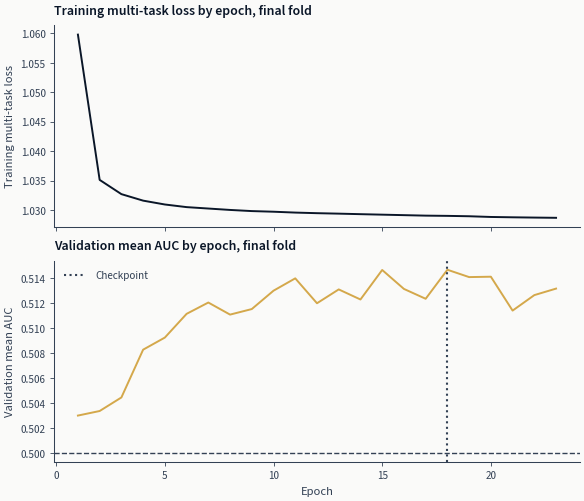

In [24]:
latest_history = pl.DataFrame(fold_records[-1]["history"])
selected_epoch = fold_records[-1]["best_epoch"]
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], sharex=True, constrained_layout=True)
axes[0].plot(latest_history["epoch"], latest_history["train_loss"], color=COLORS["blue"])
axes[0].set_ylabel("Training multi-task loss")
add_message_title(axes[0], "Training multi-task loss by epoch, final fold")
axes[1].plot(latest_history["epoch"], latest_history["valid_auc"], color=COLORS["amber"])
axes[1].axhline(0.5, color=COLORS["neutral"], linestyle="--", linewidth=1)
axes[1].axvline(
    selected_epoch, color=COLORS["neutral"], linestyle=":", linewidth=1.5, label="Checkpoint"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation mean AUC")
axes[1].legend()
add_message_title(axes[1], "Validation mean AUC by epoch, final fold")
show_with_alt(
    fig,
    "Two stacked panels sharing an epoch axis for the last validation fold. The upper "
    "panel plots the training multi-task loss, which drops steeply over the first few "
    "epochs and then declines slowly. The lower panel plots the validation mean AUC "
    "against a dashed reference at 0.5; it climbs off that reference in the early epochs "
    "and then wanders inside a narrow band close to it, well under 0.02 above the "
    "reference. A dotted vertical line marks the selected checkpoint epoch.",
)

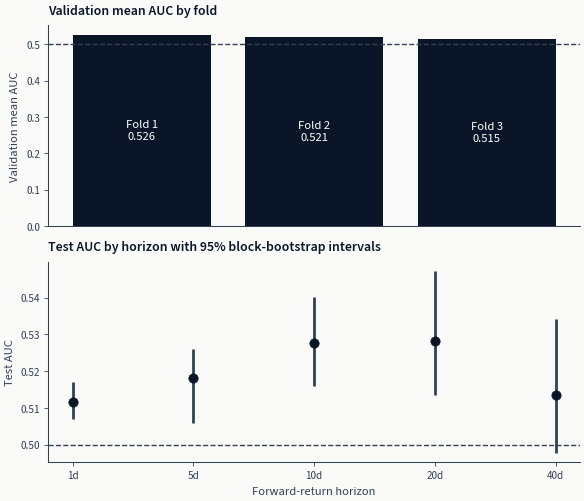

In [25]:
fold_auc = np.array([record["mean_auc"] for record in fold_records])
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"])
bars = axes[0].bar(np.arange(len(fold_auc)), fold_auc, color=COLORS["blue"])
axes[0].bar_label(
    bars,
    labels=[f"Fold {i}\n{auc:.3f}" for i, auc in enumerate(fold_auc, start=1)],
    label_type="center",
    color="white",
)
axes[0].tick_params(axis="x", bottom=False, labelbottom=False)
axes[0].axhline(0.5, color=COLORS["neutral"], linestyle="--", linewidth=1)
axes[0].set_ylabel("Validation mean AUC")
add_message_title(axes[0], "Validation mean AUC by fold")
positions = np.arange(len(horizons))
axes[1].vlines(positions, auc_low, auc_high, color=COLORS["neutral"], linewidth=2)
axes[1].scatter(positions, test_auc, color=COLORS["blue"], s=45, zorder=3)
axes[1].axhline(0.5, color=COLORS["neutral"], linestyle="--", linewidth=1)
axes[1].set_xticks(positions, [f"{h}d" for h in horizons])
axes[1].set_xlabel("Forward-return horizon")
axes[1].set_ylabel("Test AUC")
add_message_title(axes[1], "Test AUC by horizon with 95% block-bootstrap intervals")
show_with_alt(
    fig,
    "Two stacked panels. The upper panel is a bar chart of validation mean AUC for each "
    "expanding fold, each bar labeled with its fold number and value, against a dashed "
    "reference at 0.5. The bars start at zero, so the distance from that reference is a "
    "thin sliver at the top of each bar. The lower panel plots the test AUC for each "
    "forward-return horizon as a point with a vertical 95% block-bootstrap interval, "
    "against the same dashed 0.5 reference; every point sits above 0.5 and the intervals "
    "widen with the horizon.",
)

Reconstruction error diagnoses which ranked inputs the bottleneck preserves;
it is not predictive evidence. Date-local ranking puts every feature on the same
numeric range, which is what lets the bars share an axis at all. It does not give them
the same distribution: average ranks keep ties, and a characteristic like
price-to-high sits at its maximum for many stocks on any given date, so it is less
spread than a feature with no ties. A less spread feature has less to reconstruct, so
read a lower bar as a smaller error rather than as better preservation, and compare
bars whose features are shaped alike.

Reconstruction MSE across 17 characteristics: 1.06 to 1.86 (x 1e-4), ratio 1.75


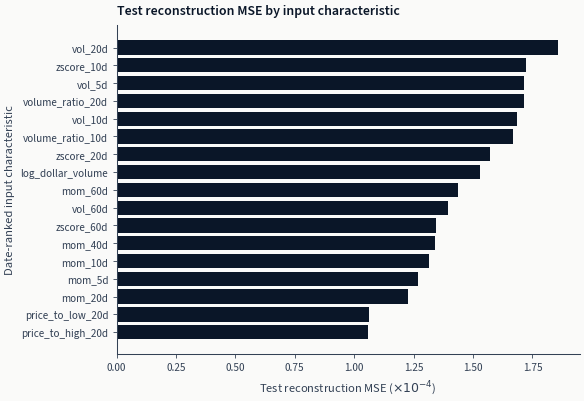

In [26]:
final_model.eval()
with torch.no_grad():
    test_features = X[test_indices].to(device)
    decoded, _, _ = final_model(test_features)
reconstruction_error = ((decoded.cpu().numpy() - test_features.cpu().numpy()) ** 2).mean(axis=0)
order = np.argsort(reconstruction_error)
scaled_error = reconstruction_error * 1e4
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
ax.barh(np.array(feature_names)[order], scaled_error[order], color=COLORS["blue"])
ax.set_xlabel(r"Test reconstruction MSE ($\times 10^{-4}$)")
ax.set_ylabel("Date-ranked input characteristic")
add_message_title(ax, "Test reconstruction MSE by input characteristic")
print(
    f"Reconstruction MSE across {len(feature_names)} characteristics: "
    f"{scaled_error.min():.2f} to {scaled_error.max():.2f} (x 1e-4), "
    f"ratio {scaled_error.max() / scaled_error.min():.2f}"
)
show_with_alt(
    fig,
    "Horizontal bar chart of test reconstruction MSE for each date-ranked input "
    "characteristic, sorted with the largest error at the top. The bars start at zero "
    "and span a narrow range: the largest is under twice the smallest, so the chart is a "
    "block of similar lengths rather than a few outliers. The volatility and z-score "
    "features sit at the high-error end and the price-to-high and price-to-low ratios at "
    "the low-error end.",
)

## 8. Takeaways

1. **Supervision changes the representation.** Reconstruction regularizes the
   encoder, while both classification heads shape it for forward direction.
2. **Global-date labels make timing explicit.** A 40-day label uses the exact
   fortieth future trading date and drops symbol gaps.
3. **Two embargoes protect test.** Every validation fold is purged, and the
   last validation label ends before the test price window begins.
4. **Checkpoint copies are immutable.** Deep copies restore the actual
   validation-AUC maximum rather than the final epoch's mutated tensors.
5. **AUC needs dependence-aware uncertainty.** Forty-date block intervals
   accompany every test horizon; reconstruction error remains a model
   diagnostic, not evidence of predictability.

The final chapter notebook,
[`09_case_study_insights`](09_case_study_insights.ipynb), compares these
latent-model lessons with the registered case-study evidence.